<a href="https://colab.research.google.com/github/rhonaeloisa/EDP_Activity_7/blob/main/Bigdata_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **BIG DATA PROJECT - MODEL TRAINING**

This notebook starts from the cleaned parquet file produced by the preprocessing notebook.


In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("risk.IT.model_training").getOrCreate()

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


**LOAD THE PARQUET FILE**

In [ ]:
path = "/content/drive/MyDrive/bigdata/df_cleaned.parquet"

df_cleaned = spark.read.parquet(path)

df_cleaned.show(5)


+----------+--------------------+------------------+---------------------+--------------+----+------------------+---------------+
|naics_code|industry_description|total_hours_worked|no_injuries_illnesses|total_injuries|size|establishment_type|year_filing_for|
+----------+--------------------+------------------+---------------------+--------------+----+------------------+---------------+
|    721110|hotels resort wit...|          323521.0|                    1|             8|   2|                 1|           2016|
|    811310|electric motor re...|           52664.0|                    1|             1|   2|                 1|           2016|
|    423220|floor coverings m...|           16852.0|                    2|             0|   1|                 1|           2016|
|    321214|trusses wood roof...|          105522.0|                    1|             2|   2|                 1|           2016|
|    541511|applications soft...|          192000.0|                    2|             0| 

# **FEATURE ENGINEERING AND MODEL TRAINING**

This section keeps the original parquet workflow:

1. The preprocessing notebook saves `df_cleaned.parquet`.
2. The model-training notebook loads `df_cleaned.parquet`.

The model code below is corrected only where needed to match the objectives.


## **Objective 1: Regression Model**

Objective: predict the expected number of workplace incidents using historical data.

Target: `total_injuries`


In [ ]:
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, FeatureHasher
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor, GeneralizedLinearRegression
from pyspark.ml.classification import RandomForestClassifier, DecisionTreeClassifier
from pyspark.ml.evaluation import RegressionEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Feature engineering for Objective 1 regression.
# total_injuries is the original count label. log_total_injuries is added for skewed-count modeling.
# Poisson regression requires a non-negative label, so invalid negative injury counts are removed.
df_reg = df_cleaned.fillna({
    "naics_code": 0,
    "total_hours_worked": 0.0,
    "no_injuries_illnesses": 0,
    "size": 0,
    "establishment_type": 0,
    "year_filing_for": 0,
    "total_injuries": 0
}).filter(
    F.col("total_injuries") >= 0
).withColumn(
    "injury_illness_rate_per_200k",
    F.when(
        F.col("total_hours_worked") > 0,
        (F.col("no_injuries_illnesses") / F.col("total_hours_worked")) * F.lit(200000.0)
    ).otherwise(F.lit(0.0))
).withColumn(
    "log_total_hours_worked",
    F.log(F.col("total_hours_worked") + F.lit(1.0))
).withColumn(
    "log_total_injuries",
    F.log(F.col("total_injuries") + F.lit(1.0))
).fillna({
    "log_total_hours_worked": 0.0,
    "injury_illness_rate_per_200k": 0.0,
    "log_total_injuries": 0.0
})

regression_feature_cols = [
    "naics_code",
    "total_hours_worked",
    "log_total_hours_worked",
    "no_injuries_illnesses",
    "injury_illness_rate_per_200k",
    "size",
    "establishment_type",
    "year_filing_for"
]

invalid_negative_injury_rows = df_cleaned.filter(F.col("total_injuries") < 0).count()
print("Rows removed because total_injuries was negative:", invalid_negative_injury_rows)

train_reg, test_reg = df_reg.select(regression_feature_cols + ["total_injuries", "log_total_injuries"]).randomSplit([0.8, 0.2], seed=42)

# Keep the original train/test parquet workflow.
train_reg.write.mode("overwrite").parquet("/content/train_regression.parquet")
test_reg.write.mode("overwrite").parquet("/content/test_regression.parquet")

assembler_reg = VectorAssembler(inputCols=regression_feature_cols, outputCol="features")


Rows removed because total_injuries was negative: 2


In [ ]:
# Baseline regression models using PySpark Pipeline
lr = LinearRegression(featuresCol="features", labelCol="total_injuries")
rf_regressor = RandomForestRegressor(
    featuresCol="features",
    labelCol="total_injuries",
    numTrees=50,
    maxDepth=8,
    seed=42
)
gbt_regressor = GBTRegressor(
    featuresCol="features",
    labelCol="total_injuries",
    maxIter=20,
    maxDepth=5,
    seed=42
)
log_gbt_regressor_baseline = GBTRegressor(
    featuresCol="features",
    labelCol="log_total_injuries",
    maxIter=20,
    maxDepth=5,
    seed=42
)
poisson_glr_baseline = GeneralizedLinearRegression(
    featuresCol="features",
    labelCol="total_injuries",
    family="poisson",
    link="log",
    maxIter=10,
    regParam=0.0
)

lr_pipeline = Pipeline(stages=[assembler_reg, lr])
rf_pipeline = Pipeline(stages=[assembler_reg, rf_regressor])
gbt_pipeline = Pipeline(stages=[assembler_reg, gbt_regressor])
log_gbt_pipeline_baseline = Pipeline(stages=[assembler_reg, log_gbt_regressor_baseline])
poisson_pipeline_baseline = Pipeline(stages=[assembler_reg, poisson_glr_baseline])

lr_model = lr_pipeline.fit(train_reg)
lr_predictions = lr_model.transform(test_reg)

rf_model = rf_pipeline.fit(train_reg)
rf_predictions = rf_model.transform(test_reg)

gbt_model = gbt_pipeline.fit(train_reg)
gbt_predictions = gbt_model.transform(test_reg)

log_gbt_model_baseline = log_gbt_pipeline_baseline.fit(train_reg)
log_gbt_baseline_raw = log_gbt_model_baseline.transform(test_reg)
log_gbt_baseline_predictions = log_gbt_baseline_raw.withColumn(
    "prediction_count",
    F.greatest(F.exp(F.col("prediction")) - F.lit(1.0), F.lit(0.0))
)

poisson_model_baseline = poisson_pipeline_baseline.fit(train_reg)
poisson_baseline_predictions = poisson_model_baseline.transform(test_reg)

reg_rmse = RegressionEvaluator(labelCol="total_injuries", predictionCol="prediction", metricName="rmse")
reg_mae = RegressionEvaluator(labelCol="total_injuries", predictionCol="prediction", metricName="mae")
reg_r2 = RegressionEvaluator(labelCol="total_injuries", predictionCol="prediction", metricName="r2")

reg_rmse_count = RegressionEvaluator(labelCol="total_injuries", predictionCol="prediction_count", metricName="rmse")
reg_mae_count = RegressionEvaluator(labelCol="total_injuries", predictionCol="prediction_count", metricName="mae")
reg_r2_count = RegressionEvaluator(labelCol="total_injuries", predictionCol="prediction_count", metricName="r2")

log_rmse = RegressionEvaluator(labelCol="log_total_injuries", predictionCol="prediction", metricName="rmse")

def get_regression_metrics(model_name, training_stage, predictions_df, prediction_col="prediction"):
    if prediction_col == "prediction_count":
        return {
            "Model": model_name,
            "Training Stage": training_stage,
            "RMSE": reg_rmse_count.evaluate(predictions_df),
            "MAE": reg_mae_count.evaluate(predictions_df),
            "R2": reg_r2_count.evaluate(predictions_df)
        }
    return {
        "Model": model_name,
        "Training Stage": training_stage,
        "RMSE": reg_rmse.evaluate(predictions_df),
        "MAE": reg_mae.evaluate(predictions_df),
        "R2": reg_r2.evaluate(predictions_df)
    }

baseline_regression_results = pd.DataFrame([
    get_regression_metrics("Linear Regression", "Baseline", lr_predictions),
    get_regression_metrics("Random Forest", "Baseline", rf_predictions),
    get_regression_metrics("GBT Regressor", "Baseline", gbt_predictions),
    get_regression_metrics("Log-Target GBT", "Baseline", log_gbt_baseline_predictions, prediction_col="prediction_count"),
    get_regression_metrics("Poisson GLR", "Baseline", poisson_baseline_predictions)
])

baseline_regression_results


,Model,Training Stage,RMSE,MAE,R2
0,Linear Regression,Baseline,15.016300,4.143789,0.134105
1,Random Forest,Baseline,14.139354,3.067065,0.232288
2,GBT Regressor,Baseline,14.011878,3.051809,0.246068
3,Log-Target GBT,Baseline,14.616720,2.749693,0.179574
4,Poisson GLR,Baseline,27.943280,3.285589,-1.998431


In [ ]:
# Fine-tune Random Forest, GBT, Log-Target GBT, and Poisson GLR using PySpark Pipeline
rf_regressor_tuned = RandomForestRegressor(
    featuresCol="features",
    labelCol="total_injuries",
    seed=42
)
rf_tuned_pipeline = Pipeline(stages=[assembler_reg, rf_regressor_tuned])

paramGrid_rf_reg = (
    ParamGridBuilder()
    .addGrid(rf_regressor_tuned.numTrees, [50, 100, 150])
    .addGrid(rf_regressor_tuned.maxDepth, [6, 8, 10])
    .addGrid(rf_regressor_tuned.minInstancesPerNode, [1, 3])
    .build()
)

rf_reg_tvs = TrainValidationSplit(
    estimator=rf_tuned_pipeline,
    estimatorParamMaps=paramGrid_rf_reg,
    evaluator=reg_rmse,
    trainRatio=0.8,
    parallelism=2,
    seed=42
)

rf_reg_tvs_model = rf_reg_tvs.fit(train_reg)
tuned_rf_predictions = rf_reg_tvs_model.transform(test_reg)
tuned_rf_reg_model = rf_reg_tvs_model.bestModel.stages[-1]

# Fine-tuned standard GBT on total_injuries.
gbt_regressor_tuned = GBTRegressor(
    featuresCol="features",
    labelCol="total_injuries",
    seed=42
)
gbt_tuned_pipeline = Pipeline(stages=[assembler_reg, gbt_regressor_tuned])

paramGrid_gbt_reg = (
    ParamGridBuilder()
    .addGrid(gbt_regressor_tuned.maxIter, [20, 40])
    .addGrid(gbt_regressor_tuned.maxDepth, [4, 6])
    .addGrid(gbt_regressor_tuned.stepSize, [0.05, 0.1])
    .build()
)

gbt_reg_tvs = TrainValidationSplit(
    estimator=gbt_tuned_pipeline,
    estimatorParamMaps=paramGrid_gbt_reg,
    evaluator=reg_rmse,
    trainRatio=0.8,
    parallelism=2,
    seed=42
)

gbt_reg_tvs_model = gbt_reg_tvs.fit(train_reg)
tuned_gbt_predictions = gbt_reg_tvs_model.transform(test_reg)
tuned_gbt_model = gbt_reg_tvs_model.bestModel.stages[-1]

# Fine-tuned GBT on log(total_injuries + 1), then convert prediction back to injury counts.
log_gbt_regressor = GBTRegressor(
    featuresCol="features",
    labelCol="log_total_injuries",
    seed=42
)
log_gbt_pipeline = Pipeline(stages=[assembler_reg, log_gbt_regressor])

paramGrid_log_gbt = (
    ParamGridBuilder()
    .addGrid(log_gbt_regressor.maxIter, [20, 40])
    .addGrid(log_gbt_regressor.maxDepth, [4, 6])
    .addGrid(log_gbt_regressor.stepSize, [0.05, 0.1])
    .build()
)

log_gbt_tvs = TrainValidationSplit(
    estimator=log_gbt_pipeline,
    estimatorParamMaps=paramGrid_log_gbt,
    evaluator=log_rmse,
    trainRatio=0.8,
    parallelism=2,
    seed=42
)

log_gbt_tvs_model = log_gbt_tvs.fit(train_reg)
log_gbt_predictions_raw = log_gbt_tvs_model.transform(test_reg)
log_gbt_predictions = log_gbt_predictions_raw.withColumn(
    "prediction_count",
    F.greatest(F.exp(F.col("prediction")) - F.lit(1.0), F.lit(0.0))
)
tuned_log_gbt_model = log_gbt_tvs_model.bestModel.stages[-1]

# Fine-tuned Poisson Generalized Linear Regression for count prediction.
poisson_glr = GeneralizedLinearRegression(
    featuresCol="features",
    labelCol="total_injuries",
    family="poisson",
    link="log"
)
poisson_pipeline = Pipeline(stages=[assembler_reg, poisson_glr])

paramGrid_poisson = (
    ParamGridBuilder()
    .addGrid(poisson_glr.regParam, [0.0, 0.01, 0.1])
    .addGrid(poisson_glr.maxIter, [10, 25])
    .build()
)

poisson_tvs = TrainValidationSplit(
    estimator=poisson_pipeline,
    estimatorParamMaps=paramGrid_poisson,
    evaluator=reg_rmse,
    trainRatio=0.8,
    parallelism=2,
    seed=42
)

poisson_tvs_model = poisson_tvs.fit(train_reg)
poisson_predictions = poisson_tvs_model.transform(test_reg)
tuned_poisson_model = poisson_tvs_model.bestModel.stages[-1]

tuned_regression_results = pd.DataFrame([
    get_regression_metrics("Linear Regression", "Baseline", lr_predictions),
    get_regression_metrics("Random Forest", "Baseline", rf_predictions),
    get_regression_metrics("Random Forest", "Fine-tuned", tuned_rf_predictions),
    get_regression_metrics("GBT Regressor", "Baseline", gbt_predictions),
    get_regression_metrics("GBT Regressor", "Fine-tuned", tuned_gbt_predictions),
    get_regression_metrics("Log-Target GBT", "Baseline", log_gbt_baseline_predictions, prediction_col="prediction_count"),
    get_regression_metrics("Log-Target GBT", "Fine-tuned", log_gbt_predictions, prediction_col="prediction_count"),
    get_regression_metrics("Poisson GLR", "Baseline", poisson_baseline_predictions),
    get_regression_metrics("Poisson GLR", "Fine-tuned", poisson_predictions)
])

best_regression_row = tuned_regression_results.sort_values("RMSE", ascending=True).iloc[0]
best_regression_model_name = best_regression_row["Model"]
best_regression_stage = best_regression_row["Training Stage"]

if best_regression_model_name == "Linear Regression":
    best_regression_predictions = lr_predictions
    best_prediction_col = "prediction"
elif best_regression_model_name == "Random Forest" and best_regression_stage == "Baseline":
    best_regression_predictions = rf_predictions
    best_prediction_col = "prediction"
elif best_regression_model_name == "Random Forest" and best_regression_stage == "Fine-tuned":
    best_regression_predictions = tuned_rf_predictions
    best_prediction_col = "prediction"
elif best_regression_model_name == "GBT Regressor" and best_regression_stage == "Baseline":
    best_regression_predictions = gbt_predictions
    best_prediction_col = "prediction"
elif best_regression_model_name == "GBT Regressor" and best_regression_stage == "Fine-tuned":
    best_regression_predictions = tuned_gbt_predictions
    best_prediction_col = "prediction"
elif best_regression_model_name == "Log-Target GBT" and best_regression_stage == "Baseline":
    best_regression_predictions = log_gbt_baseline_predictions
    best_prediction_col = "prediction_count"
elif best_regression_model_name == "Log-Target GBT" and best_regression_stage == "Fine-tuned":
    best_regression_predictions = log_gbt_predictions
    best_prediction_col = "prediction_count"
elif best_regression_model_name == "Poisson GLR" and best_regression_stage == "Baseline":
    best_regression_predictions = poisson_baseline_predictions
    best_prediction_col = "prediction"
else:
    best_regression_predictions = poisson_predictions
    best_prediction_col = "prediction"

print("Best RF numTrees:", tuned_rf_reg_model.getNumTrees)
print("Best RF maxDepth:", tuned_rf_reg_model.getMaxDepth())
print("Best RF minInstancesPerNode:", tuned_rf_reg_model.getMinInstancesPerNode())
print("Best GBT maxIter:", tuned_gbt_model.getMaxIter())
print("Best GBT maxDepth:", tuned_gbt_model.getMaxDepth())
print("Best GBT stepSize:", tuned_gbt_model.getStepSize())
print("Best Log-Target GBT maxIter:", tuned_log_gbt_model.getMaxIter())
print("Best Log-Target GBT maxDepth:", tuned_log_gbt_model.getMaxDepth())
print("Best Log-Target GBT stepSize:", tuned_log_gbt_model.getStepSize())
print("Best Poisson regParam:", tuned_poisson_model.getRegParam())
print("Best Poisson maxIter:", tuned_poisson_model.getMaxIter())
print("Best prediction model by RMSE:", best_regression_model_name)
print("Best prediction result type:", best_regression_stage)

tuned_regression_results


Best RF numTrees: 100
Best RF maxDepth: 10
Best RF minInstancesPerNode: 1
Best GBT maxIter: 40
Best GBT maxDepth: 6
Best GBT stepSize: 0.1
Best Log-Target GBT maxIter: 40
Best Log-Target GBT maxDepth: 6
Best Log-Target GBT stepSize: 0.1
Best Poisson regParam: 0.0
Best Poisson maxIter: 10
Best prediction model by RMSE: GBT Regressor
Best prediction result type: Fine-tuned


,Model,Training Stage,RMSE,MAE,R2
0,Linear Regression,Baseline,15.016300,4.143789,0.134105
1,Random Forest,Baseline,14.139354,3.067065,0.232288
2,Random Forest,Fine-tuned,14.074478,3.037855,0.239317
3,GBT Regressor,Baseline,14.011878,3.051809,0.246068
4,GBT Regressor,Fine-tuned,13.988127,3.025884,0.248622
5,Log-Target GBT,Baseline,14.616720,2.749693,0.179574
6,Log-Target GBT,Fine-tuned,14.505644,2.722663,0.191996
7,Poisson GLR,Baseline,27.943280,3.285589,-1.998431
8,Poisson GLR,Fine-tuned,27.943280,3.285589,-1.998431


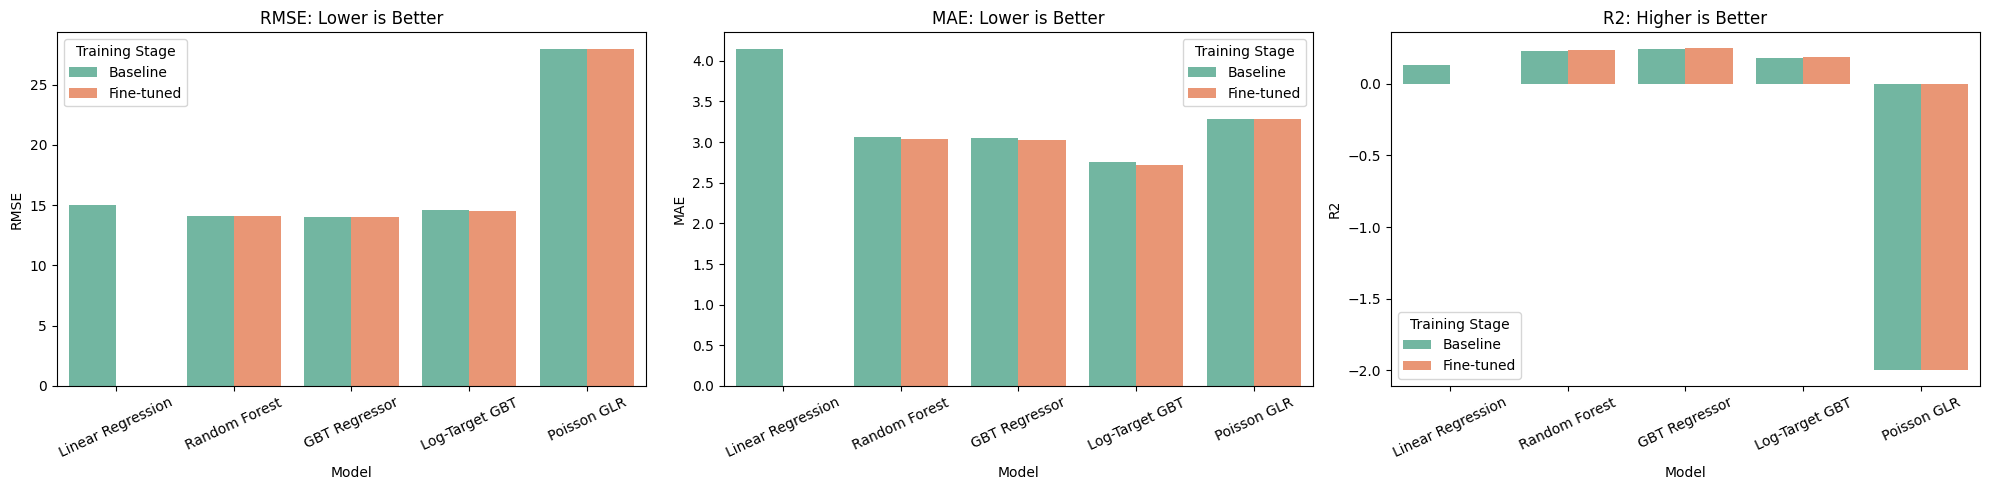

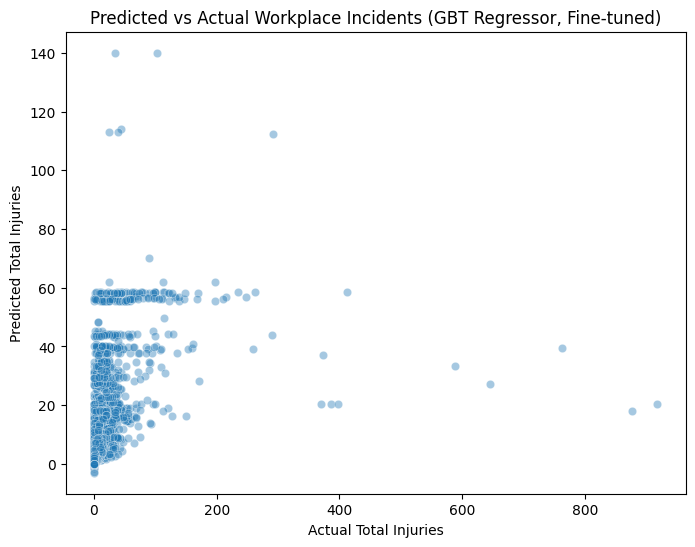

Best Prediction Model: GBT Regressor
Result Type: Fine-tuned
Best RMSE: 13.9881
Best MAE : 3.0259
Best R2  : 0.2486


In [ ]:
# Visualization: Regression model comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.barplot(data=tuned_regression_results, x="Model", y="RMSE", hue="Training Stage", ax=axes[0], palette="Set2")
axes[0].set_title("RMSE: Lower is Better")
axes[0].tick_params(axis="x", rotation=25)

sns.barplot(data=tuned_regression_results, x="Model", y="MAE", hue="Training Stage", ax=axes[1], palette="Set2")
axes[1].set_title("MAE: Lower is Better")
axes[1].tick_params(axis="x", rotation=25)

sns.barplot(data=tuned_regression_results, x="Model", y="R2", hue="Training Stage", ax=axes[2], palette="Set2")
axes[2].set_title("R2: Higher is Better")
axes[2].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

plot_reg = best_regression_predictions.select(
    F.col("total_injuries"),
    F.col(best_prediction_col).alias("prediction")
).sample(False, 0.05, seed=42).toPandas()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_reg, x="total_injuries", y="prediction", alpha=0.4)
plt.title(f"Predicted vs Actual Workplace Incidents ({best_regression_model_name}, {best_regression_stage})")
plt.xlabel("Actual Total Injuries")
plt.ylabel("Predicted Total Injuries")
plt.show()

if best_prediction_col == "prediction_count":
    best_rmse = reg_rmse_count.evaluate(best_regression_predictions)
    best_mae = reg_mae_count.evaluate(best_regression_predictions)
    best_r2 = reg_r2_count.evaluate(best_regression_predictions)
else:
    best_rmse = reg_rmse.evaluate(best_regression_predictions)
    best_mae = reg_mae.evaluate(best_regression_predictions)
    best_r2 = reg_r2.evaluate(best_regression_predictions)

print(f"Best Prediction Model: {best_regression_model_name}")
print(f"Result Type: {best_regression_stage}")
print(f"Best RMSE: {best_rmse:.4f}")
print(f"Best MAE : {best_mae:.4f}")
print(f"Best R2  : {best_r2:.4f}")


## **Objective 2: Industry Risk Classification**

Objective: classify industries into **Low**, **Medium**, or **High** workplace risk.

Industry is represented using `naics_code` and `industry_description`.


In [ ]:
# Aggregate records by NAICS industry.
industry_agg = (
    df_cleaned
    .fillna({
        "naics_code": 0,
        "industry_description": "unknown",
        "total_injuries": 0,
        "no_injuries_illnesses": 0,
        "total_hours_worked": 0.0
    })
    .groupBy("naics_code", "industry_description")
    .agg(
        F.sum("total_injuries").alias("industry_total_injuries"),
        F.sum("no_injuries_illnesses").alias("industry_total_injuries_illnesses"),
        F.sum("total_hours_worked").alias("industry_total_hours"),
        F.count("*").alias("job_count"),
        F.avg("total_injuries").alias("avg_injuries_per_job"),
        F.avg("no_injuries_illnesses").alias("avg_injuries_illnesses_per_job")
    )
    .withColumn(
        "industry_injury_rate_per_200k",
        F.when(
            F.col("industry_total_hours") > 0,
            (F.col("industry_total_injuries") / F.col("industry_total_hours")) * F.lit(200000.0)
        ).otherwise(F.lit(0.0))
    )
)

# Create Low/Medium/High industry risk levels using injury-count quantiles.
# These injury-count columns define the label and are intentionally excluded from classifier features later.
low_cutoff, high_cutoff = industry_agg.approxQuantile("avg_injuries_per_job", [0.33, 0.66], 0.05)

industry_labeled = industry_agg.withColumn(
    "industry_risk_level",
    F.when(F.col("avg_injuries_per_job") <= F.lit(low_cutoff), "Low")
     .when(F.col("avg_injuries_per_job") <= F.lit(high_cutoff), "Medium")
     .otherwise("High")
).withColumn(
    "industry_risk_index",
    F.when(F.col("industry_risk_level") == "Low", F.lit(0.0))
     .when(F.col("industry_risk_level") == "Medium", F.lit(1.0))
     .otherwise(F.lit(2.0))
).withColumn(
    "industry_label",
    F.concat_ws(" - ", F.col("naics_code").cast("string"), F.col("industry_description"))
)

print(f"Low/Medium cutoff : {low_cutoff:.4f}")
print(f"Medium/High cutoff: {high_cutoff:.4f}")
industry_labeled.groupBy("industry_risk_level", "industry_risk_index").count().orderBy("industry_risk_index").show()


NameError: name 'df_cleaned' is not defined

In [ ]:
# Visualization: Industry risk distribution and top risky industries
industry_distribution = industry_labeled.groupBy("industry_risk_level").count().toPandas()

plt.figure(figsize=(8, 5))
sns.barplot(data=industry_distribution, x="industry_risk_level", y="count", order=["Low", "Medium", "High"], palette="Set2")
plt.title("Industry Risk-Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of NAICS Industries")
plt.show()

top_industries = industry_labeled.orderBy(F.desc("avg_injuries_per_job")).limit(15).toPandas()

plt.figure(figsize=(12, 7))
sns.barplot(data=top_industries, x="avg_injuries_per_job", y="industry_label", hue="industry_risk_level", dodge=False, palette="Set2")
plt.title("Top NAICS Industries by Average Injuries per Job")
plt.xlabel("Average Injuries per Job")
plt.ylabel("NAICS Code - Industry")
plt.show()


In [ ]:
# Assemble leakage-free industry-level classification features.
# Removed leakage features: industry_total_injuries, avg_injuries_per_job, industry_injury_rate_per_200k.
# Those columns are directly used to create the industry_risk_level label.
classification_feature_cols = [
    "naics_code",
    "industry_total_hours",
    "job_count",
    "industry_total_injuries_illnesses",
    "avg_injuries_illnesses_per_job"
]

assembler_industry = VectorAssembler(inputCols=classification_feature_cols, outputCol="features")

print("Leakage-free classifier inputs:")
for feature in classification_feature_cols:
    print("-", feature)

df_industry_class = industry_labeled.select(
    "naics_code",
    "industry_description",
    "industry_label",
    "industry_total_hours",
    "job_count",
    "industry_total_injuries_illnesses",
    "avg_injuries_illnesses_per_job",
    "industry_risk_level",
    "industry_risk_index"
)

train_class, test_class = df_industry_class.randomSplit([0.8, 0.2], seed=42)

# Keep train/test parquet outputs for the model-training workflow.
train_class.write.mode("overwrite").parquet("/content/train_industry_classification.parquet")
test_class.write.mode("overwrite").parquet("/content/test_industry_classification.parquet")


In [ ]:
# Baseline Random Forest, tuned Random Forest, and Decision Tree Classifier using PySpark Pipeline
industry_rf = RandomForestClassifier(
    labelCol="industry_risk_index",
    featuresCol="features",
    numTrees=50,
    maxDepth=6,
    seed=42
)

industry_rf_pipeline = Pipeline(stages=[assembler_industry, industry_rf])
industry_rf_model = industry_rf_pipeline.fit(train_class)
industry_predictions = industry_rf_model.transform(test_class)

class_accuracy = MulticlassClassificationEvaluator(labelCol="industry_risk_index", predictionCol="prediction", metricName="accuracy")
class_f1 = MulticlassClassificationEvaluator(labelCol="industry_risk_index", predictionCol="prediction", metricName="f1")

industry_rf_tuned = RandomForestClassifier(
    labelCol="industry_risk_index",
    featuresCol="features",
    seed=42
)
industry_rf_tuned_pipeline = Pipeline(stages=[assembler_industry, industry_rf_tuned])

paramGrid_class = (
    ParamGridBuilder()
    .addGrid(industry_rf_tuned.numTrees, [50, 100, 150])
    .addGrid(industry_rf_tuned.maxDepth, [6, 8, 10])
    .addGrid(industry_rf_tuned.minInstancesPerNode, [1, 2])
    .build()
)

class_tvs = TrainValidationSplit(
    estimator=industry_rf_tuned_pipeline,
    estimatorParamMaps=paramGrid_class,
    evaluator=class_f1,
    trainRatio=0.8,
    parallelism=2,
    seed=42
)

class_tvs_model = class_tvs.fit(train_class)
tuned_industry_model = class_tvs_model.bestModel.stages[-1]
tuned_industry_predictions = class_tvs_model.transform(test_class)

industry_dt = DecisionTreeClassifier(
    labelCol="industry_risk_index",
    featuresCol="features",
    maxDepth=5,
    minInstancesPerNode=1,
    seed=42
)
industry_dt_pipeline = Pipeline(stages=[assembler_industry, industry_dt])
industry_dt_model = industry_dt_pipeline.fit(train_class)
dt_industry_predictions = industry_dt_model.transform(test_class)

classification_results = pd.DataFrame([
    {
        "Model": "Random Forest",
        "Training Stage": "Baseline",
        "Accuracy": class_accuracy.evaluate(industry_predictions),
        "Weighted F1": class_f1.evaluate(industry_predictions)
    },
    {
        "Model": "Random Forest",
        "Training Stage": "Fine-tuned",
        "Accuracy": class_accuracy.evaluate(tuned_industry_predictions),
        "Weighted F1": class_f1.evaluate(tuned_industry_predictions)
    },
    {
        "Model": "Decision Tree",
        "Training Stage": "Baseline",
        "Accuracy": class_accuracy.evaluate(dt_industry_predictions),
        "Weighted F1": class_f1.evaluate(dt_industry_predictions)
    }
])

best_classification_row = classification_results.sort_values("Accuracy", ascending=False).iloc[0]
best_model_name = best_classification_row["Model"]
best_model_stage = best_classification_row["Training Stage"]

if best_model_name == "Decision Tree":
    best_industry_predictions = dt_industry_predictions
elif best_model_name == "Random Forest" and best_model_stage == "Baseline":
    best_industry_predictions = industry_predictions
else:
    best_industry_predictions = tuned_industry_predictions

print("Best RF numTrees:", tuned_industry_model.getNumTrees)
print("Best RF maxDepth:", tuned_industry_model.getMaxDepth())
print("Best RF minInstancesPerNode:", tuned_industry_model.getMinInstancesPerNode())
print("Best model by accuracy:", best_model_name)
print("Best classification result type:", best_model_stage)

classification_results


Best RF numTrees: 50
Best RF maxDepth: 10
Best RF minInstancesPerNode: 1
Best model by accuracy: Random Forest
Best classification result type: Fine-tuned


,Model,Training Stage,Accuracy,Weighted F1
0,Random Forest,Baseline,0.736560,0.730417
1,Random Forest,Fine-tuned,0.742343,0.737717
2,Decision Tree,Baseline,0.725209,0.717598


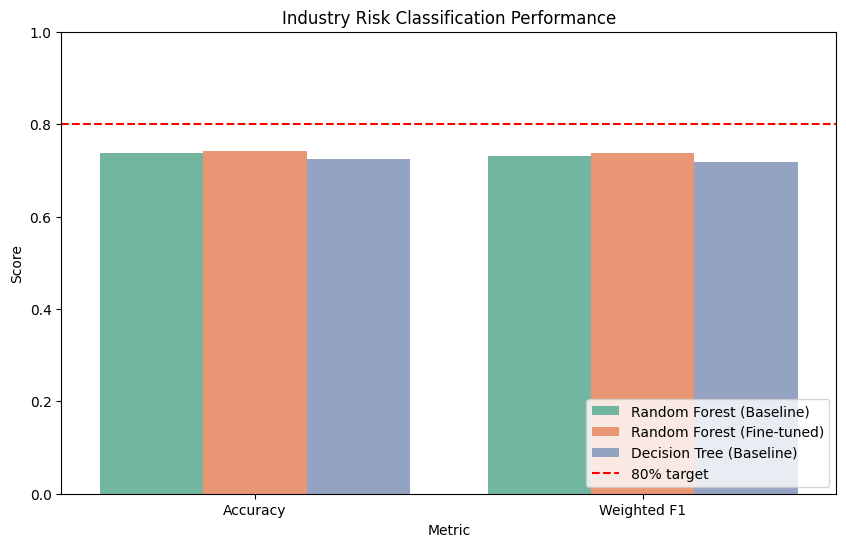

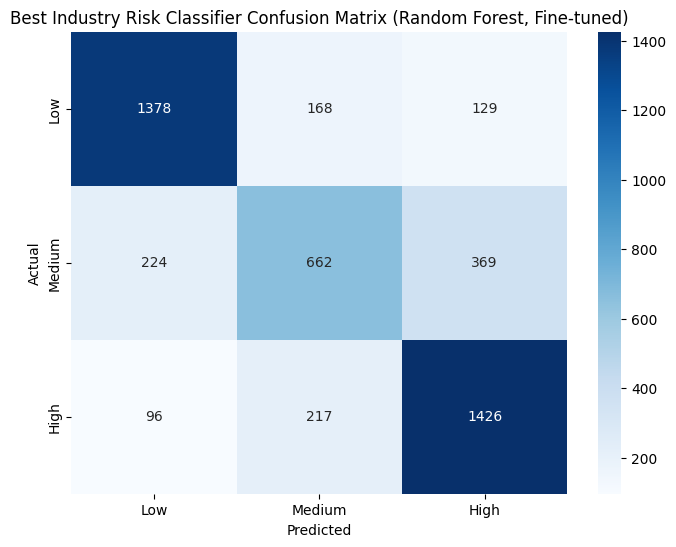

Best Model: Random Forest
Result Type: Fine-tuned
Best Accuracy: 0.7423
Best Weighted F1: 0.7377
              precision    recall  f1-score   support

         Low       0.81      0.82      0.82      1675
      Medium       0.63      0.53      0.58      1255
        High       0.74      0.82      0.78      1739

    accuracy                           0.74      4669
   macro avg       0.73      0.72      0.72      4669
weighted avg       0.74      0.74      0.74      4669



In [ ]:
# Visualization: Classification performance and confusion matrix
classification_long = classification_results.melt(
    id_vars=["Model", "Training Stage"],
    value_vars=["Accuracy", "Weighted F1"],
    var_name="Metric",
    value_name="Score"
)
classification_long["Result Type"] = classification_long["Model"] + " (" + classification_long["Training Stage"] + ")"

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=classification_long, x="Metric", y="Score", hue="Result Type", palette="Set2")
ax.axhline(0.80, color="red", linestyle="--", linewidth=1.5, label="80% target")
ax.set_ylim(0, 1)
ax.set_title("Industry Risk Classification Performance")
ax.legend(loc="lower right")
plt.show()

risk_labels = ["Low", "Medium", "High"]
y_true = best_industry_predictions.select("industry_risk_index").toPandas()["industry_risk_index"]
y_pred = best_industry_predictions.select("prediction").toPandas()["prediction"]
cm = confusion_matrix(y_true, y_pred, labels=[0.0, 1.0, 2.0])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=risk_labels, yticklabels=risk_labels)
plt.title(f"Best Industry Risk Classifier Confusion Matrix ({best_model_name}, {best_model_stage})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

best_accuracy = class_accuracy.evaluate(best_industry_predictions)
best_f1 = class_f1.evaluate(best_industry_predictions)
print(f"Best Model: {best_model_name}")
print(f"Result Type: {best_model_stage}")
print(f"Best Accuracy: {best_accuracy:.4f}")
print(f"Best Weighted F1: {best_f1:.4f}")
print(classification_report(y_true, y_pred, target_names=risk_labels, zero_division=0))
